Connecting to NOAA NCEI server...
Slicing bathymetry data...
Data loaded! Plotting...


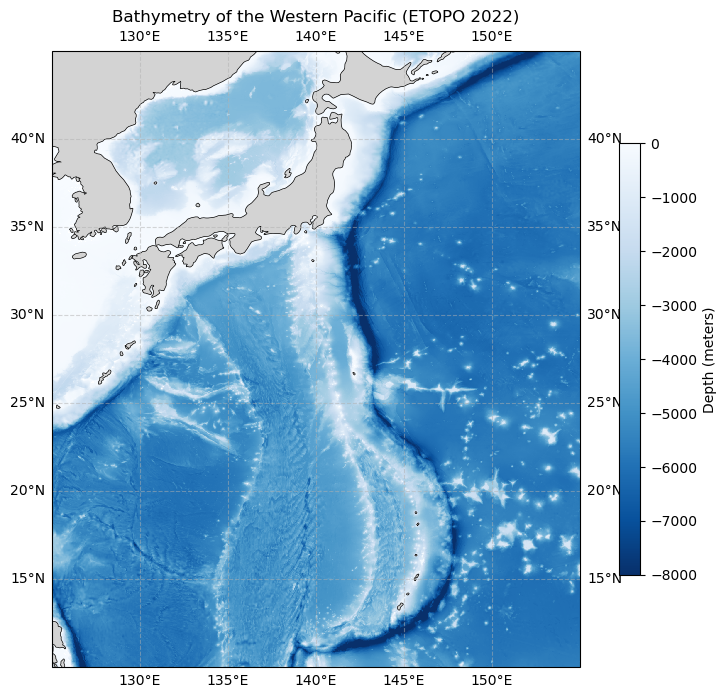

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Connecting to NOAA NCEI THREDDS server for ETOPO 2022
url = "https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO2022/60s/60s_bed_elev_netcdf/ETOPO_2022_v1_60s_N90W180_bed.nc"
print("Connecting to NOAA NCEI server...")
ds = xr.open_dataset(url)

# 2. Slicing the data for the Western Pacific (Japan and the Mariana Trench)
print("Slicing bathymetry data...")
bathy = ds.z.sel(lat=slice(10, 45), lon=slice(125, 155))

# 3. Filtering out land and only using negative depth
ocean_depth = bathy.where(bathy < 0)

print("Data loaded! Plotting...")

# 4. Seting up the map figure
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 5. Adding geographical features
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# 6. Ploting the bathymetry using a sequential blue colormap
pcm = ax.pcolormesh(
    ocean_depth.lon, ocean_depth.lat, ocean_depth,
    transform=ccrs.PlateCarree(),
    cmap='Blues_r',
    vmin=-8000, vmax=0, # Scale from 8000m deep to the surface
    zorder=1
)

# 7. Adding colorbar and labels
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('Depth (meters)')

plt.title('Bathymetry of the Western Pacific (ETOPO 2022)')

# 8. Saving output figure
plt.savefig("../figures/western_pacific_bathymetry.png", dpi=300, bbox_inches='tight')
plt.show()